# Ensayo Técnico: Estructuras de Datos y Algoritmos
## Análisis Profundo — Semanas 7, 8 y 9

**Asignatura:** Diseño de Datos y Algoritmos  
**Contenido:** Pilas · Colas · Stacks Monotónicos · Árboles BST · Árboles AVL · Grafos · BFS · DFS  

---


In [1]:
import math
import sys
import time
import random
from collections import deque

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

matplotlib.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
ACCENT = '#58a6ff'
GREEN  = '#3fb950'
ORANGE = '#d29922'
RED    = '#f85149'
PURPLE = '#bc8cff'
CYAN   = '#39d353'


---
# I. Estructuras Lineales: Pilas y Colas
## Semana 7

Las estructuras lineales constituyen el primer nivel de abstracción sobre los arreglos básicos. Una **pila (stack)** respeta la política LIFO (*Last-In, First-Out*) y una **cola (queue)** respeta FIFO (*First-In, First-Out*). Ambas son primitivas fundamentales sobre las que se construyen algoritmos de búsqueda, planificación y evaluación de expresiones.

---
## 1.1 Pila (Stack) — Implementación y Análisis


In [2]:
class Pila:
    """Pila LIFO implementada sobre lista Python (sin módulos externos)."""

    def __init__(self):
        self._datos = []

    def push(self, valor):
        """O(1) amortizado — inserta en la cima."""
        self._datos.append(valor)

    def pop(self):
        """O(1) — extrae el elemento de la cima."""
        if self.esta_vacia():
            raise IndexError("pop en pila vacía")
        return self._datos.pop()

    def top(self):
        """O(1) — consulta sin extraer."""
        if self.esta_vacia():
            raise IndexError("top en pila vacía")
        return self._datos[-1]

    def esta_vacia(self):
        return len(self._datos) == 0

    def tamaño(self):
        return len(self._datos)

    def __repr__(self):
        return f"Pila({self._datos})"


# ── Demostración ──────────────────────────────────────────────────────────────
p = Pila()
for v in [10, 25, 7, 33, 18]:
    p.push(v)
print("Pila tras inserciones:", p)
print("Cima:", p.top())
print("Extraído:", p.pop())
print("Pila resultante:     ", p)


Pila tras inserciones: Pila([10, 25, 7, 33, 18])
Cima: 18
Extraído: 18
Pila resultante:      Pila([10, 25, 7, 33])


### Visualización: comportamiento LIFO de la pila


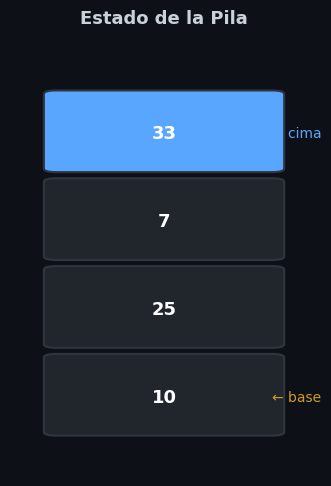

In [3]:
def visualizar_pila(elementos, titulo='Pila (LIFO)'):
    fig, ax = plt.subplots(figsize=(3.5, 5))
    ax.set_xlim(0, 1); ax.set_ylim(-0.5, len(elementos) + 0.5)
    ax.set_title(titulo, pad=10)
    ax.axis('off')
    for i, val in enumerate(elementos):
        color = ACCENT if i == len(elementos) - 1 else '#21262d'
        rect = mpatches.FancyBboxPatch(
            (0.15, i), 0.70, 0.85,
            boxstyle="round,pad=0.04",
            linewidth=1.5, edgecolor='#30363d', facecolor=color)
        ax.add_patch(rect)
        ax.text(0.50, i + 0.40, str(val),
                ha='center', va='center', fontsize=13, color='white', fontweight='bold')
    if elementos:
        ax.annotate('← cima', xy=(0.85, len(elementos) - 1 + 0.40),
                    fontsize=10, color=ACCENT, va='center')
    ax.annotate('← base', xy=(0.85, 0.40),
                fontsize=10, color=ORANGE, va='center')
    plt.tight_layout(); plt.show()

visualizar_pila([10, 25, 7, 33], titulo='Estado de la Pila')


---
## 1.2 Cola (Queue) — Implementación con Dos Pilas

La implementación ingenua de una cola mediante una lista Python recurre a `pop(0)`, que tiene costo **O(n)** por desplazamiento. La solución óptima emplea **dos pilas** para lograr costo **O(1) amortizado** por operación.

**Principio:** los elementos ingresan en `in_stack`; cuando se necesita desencolar, se transfiere *todo* `in_stack` a `out_stack` (invirtiendo el orden), operación que solo ocurre cuando `out_stack` está vacía.


In [4]:
class Cola:
    """Cola FIFO implementada con dos pilas — dequeue amortizado O(1)."""

    def __init__(self):
        self._in  = Pila()   # Recibe nuevos elementos
        self._out = Pila()   # Sirve los más antiguos

    def _transferir(self):
        """Vuelca in→out sólo cuando out está vacía."""
        if self._out.esta_vacia():
            while not self._in.esta_vacia():
                self._out.push(self._in.pop())

    def enqueue(self, valor):
        """O(1) — inserta al fondo de la cola."""
        self._in.push(valor)

    def dequeue(self):
        """O(1) amortizado — extrae el frente."""
        self._transferir()
        if self._out.esta_vacia():
            raise IndexError("dequeue en cola vacía")
        return self._out.pop()

    def front(self):
        """O(1) amortizado — consulta el frente sin extraer."""
        self._transferir()
        if self._out.esta_vacia():
            raise IndexError("front en cola vacía")
        return self._out.top()

    def esta_vacia(self):
        return self._in.esta_vacia() and self._out.esta_vacia()

    def tamaño(self):
        return self._in.tamaño() + self._out.tamaño()


# ── Demostración ──────────────────────────────────────────────────────────────
cola = Cola()
for v in ['A', 'B', 'C', 'D']:
    cola.enqueue(v)
print("Frente:", cola.front())
print("Desencolar:", cola.dequeue())
cola.enqueue('E')
print("Frente tras enqueue(E):", cola.front())
print("Tamaño:", cola.tamaño())


Frente: A
Desencolar: A
Frente tras enqueue(E): B
Tamaño: 4


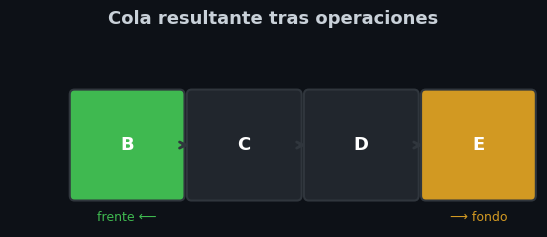

In [5]:
def visualizar_cola(elementos, titulo='Cola (FIFO)'):
    fig, ax = plt.subplots(figsize=(max(5, len(elementos) * 1.4), 2.5))
    ax.set_xlim(-0.5, len(elementos)); ax.set_ylim(0, 1.5)
    ax.set_title(titulo, pad=10); ax.axis('off')
    for i, val in enumerate(elementos):
        color = GREEN if i == 0 else ('#21262d' if i < len(elementos)-1 else ORANGE)
        rect = mpatches.FancyBboxPatch(
            (i + 0.05, 0.25), 0.90, 0.80,
            boxstyle="round,pad=0.04",
            linewidth=1.5, edgecolor='#30363d', facecolor=color)
        ax.add_patch(rect)
        ax.text(i + 0.50, 0.65, str(val),
                ha='center', va='center', fontsize=13, color='white', fontweight='bold')
        if i < len(elementos) - 1:
            ax.annotate('', xy=(i + 1.05, 0.65), xytext=(i + 0.95, 0.65),
                        arrowprops=dict(arrowstyle='->', color='#30363d', lw=2))
    ax.text(0.50,  0.05, 'frente ⟵', ha='center', fontsize=9, color=GREEN)
    ax.text(len(elementos) - 0.50, 0.05, '⟶ fondo', ha='center', fontsize=9, color=ORANGE)
    plt.tight_layout(); plt.show()

visualizar_cola(['B', 'C', 'D', 'E'], titulo='Cola resultante tras operaciones')


---
## 1.3 Stack Monotónico — Plantas Venenosas (*Poisonous Plants*)

El **stack monotónico** es una variante de la pila donde se mantiene una invariante de orden (creciente o decreciente) sobre los elementos almacenados. Su utilidad principal radica en resolver problemas de *next greater/smaller element* en **O(n)**.

**Problema:** dado un arreglo `p[]` de niveles de pesticida, en cada día todas las plantas cuyo nivel supera al de su vecino izquierdo mueren. ¿Cuántos días sobrevive alguna planta?


In [6]:
def plants(p):
    """
    Stack monotónico — O(n) tiempo, O(n) espacio.
    Retorna el número de días hasta que ninguna planta muera.
    """
    stack = []          # [(nivel_pesticida, dias_para_morir)]
    max_days = 0

    for nivel in p:
        dias = 0
        while stack and stack[-1][0] >= nivel:
            dias = max(dias, stack.pop()[1])
        if stack:          # Hay un vecino izquierdo menor → la planta morirá
            dias += 1
            max_days = max(max_days, dias)
        else:
            dias = 0       # No hay vecino → sobrevive indefinidamente
        stack.append((nivel, dias))

    return max_days


# Casos de prueba
casos = {
    'Ejemplo 1': [6, 5, 8, 4, 7, 10, 9],
    'Ejemplo 2': [3, 6, 2, 8, 5],
    'Ejemplo 3': [1, 2, 3, 4, 5],   # Ninguna muere → 0 días
    'Ejemplo 4': [5, 4, 3, 2, 1],   # Todas mueren en 1 día → 1 día
}
for nombre, arr in casos.items():
    print(f"{nombre}: {arr}  →  {plants(arr)} días")


Ejemplo 1: [6, 5, 8, 4, 7, 10, 9]  →  2 días
Ejemplo 2: [3, 6, 2, 8, 5]  →  2 días
Ejemplo 3: [1, 2, 3, 4, 5]  →  1 días
Ejemplo 4: [5, 4, 3, 2, 1]  →  0 días


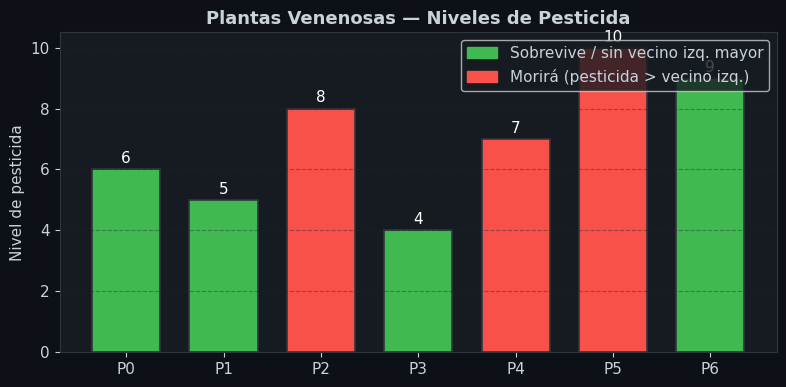

In [7]:
def visualizar_plantas(p, titulo='Plantas Venenosas — Niveles de Pesticida'):
    n = len(p)
    colores = []
    for i in range(n):
        if i == 0:
            colores.append(GREEN)
        else:
            colores.append(RED if p[i] > p[i-1] else GREEN)

    fig, ax = plt.subplots(figsize=(max(8, n * 1.1), 4))
    bars = ax.bar(range(n), p, color=colores, edgecolor='#30363d', linewidth=1.2, width=0.7)
    ax.set_xticks(range(n))
    ax.set_xticklabels([f'P{i}' for i in range(n)])
    ax.set_ylabel('Nivel de pesticida')
    ax.set_title(titulo)
    ax.grid(axis='y', alpha=0.4)
    for i, bar in enumerate(bars):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(p[i]), ha='center', va='bottom', fontsize=11, color='white')
    legend = [
        mpatches.Patch(color=GREEN, label='Sobrevive / sin vecino izq. mayor'),
        mpatches.Patch(color=RED,   label='Morirá (pesticida > vecino izq.)'),
    ]
    ax.legend(handles=legend, loc='upper right')
    plt.tight_layout(); plt.show()

visualizar_plantas([6, 5, 8, 4, 7, 10, 9])


---
## 1.4 Cola con Operaciones de Bit — AND XOR OR

El problema **And XOR Or** explota la propiedad del stack monotónico para encontrar el par de elementos adyacentes que maximiza una función sobre los bits: calcula la operación XOR entre elementos consecutivos de la pila manteniendo un orden creciente.


In [8]:
def andXorOr(arr):
    """
    Stack monotónico creciente.
    Para cada par (stack[-1], elemento_actual) calcula XOR y guarda el máximo.
    O(n) tiempo.
    """
    stack = []
    max_xor = 0

    for val in arr:
        while stack and stack[-1] <= val:
            max_xor = max(max_xor, stack.pop() ^ val)
        if stack:
            max_xor = max(max_xor, stack[-1] ^ val)
        stack.append(val)

    return max_xor


# Validación
casos_xor = [
    [9, 6, 3, 7, 10, 2, 5],
    [5, 7, 3],
    [10, 20, 30, 40],
]
for a in casos_xor:
    print(f"andXorOr({a}) = {andXorOr(a)}")


andXorOr([9, 6, 3, 7, 10, 2, 5]) = 15
andXorOr([5, 7, 3]) = 4
andXorOr([10, 20, 30, 40]) = 54


---
## 1.5 Sistema de Atención Médica con Colas de Prioridad

El sistema modela la recepción de pacientes donde los **críticos** (C) tienen prioridad absoluta sobre los **normales** (N). Ambos grupos respetan FIFO internamente, y el historial de atención se almacena en una pila.


In [9]:
class SistemaAtencionMedica:
    """
    Gestor de pacientes con dos colas (FIFO) y prioridad estricta:
      - Cola críticos: se atiende primero, en orden de llegada.
      - Cola normales: se atiende cuando no hay críticos.
      - Historial: pila de pacientes ya atendidos.
    """

    def __init__(self):
        self.cola_criticos = Cola()
        self.cola_normales = Cola()
        self.historial     = Pila()

    def agregar_paciente(self, tipo: str, nombre: str):
        tipo = tipo.upper()
        if tipo == 'C':
            self.cola_criticos.enqueue(nombre)
        elif tipo == 'N':
            self.cola_normales.enqueue(nombre)
        else:
            raise ValueError(f"Tipo de paciente inválido: '{tipo}'")

    def atender_paciente(self):
        if not self.cola_criticos.esta_vacia():
            nombre = self.cola_criticos.dequeue()
        elif not self.cola_normales.esta_vacia():
            nombre = self.cola_normales.dequeue()
        else:
            return "No hay pacientes en espera"
        self.historial.push(nombre)
        return f"Se atiende a {nombre}"

    def ultimo_atendido(self):
        return self.historial.top() if not self.historial.esta_vacia() else "Sin historial"

    def estado(self):
        return {
            'criticos_espera': self.cola_criticos.tamaño(),
            'normales_espera': self.cola_normales.tamaño(),
            'total_atendidos': self.historial.tamaño(),
        }


# ── Demostración ──────────────────────────────────────────────────────────────
sistema = SistemaAtencionMedica()
ingresos = [
    ('N', 'Ana'),  ('C', 'Luis'), ('N', 'Marta'),
    ('C', 'Juan'), ('N', 'Sofía'),('C', 'Pedro'),
]
for tipo, nombre in ingresos:
    sistema.agregar_paciente(tipo, nombre)
    print(f"Ingresó: [{tipo}] {nombre}  — estado: {sistema.estado()}")

print()
for _ in range(len(ingresos)):
    print(sistema.atender_paciente())
print("Último atendido:", sistema.ultimo_atendido())


Ingresó: [N] Ana  — estado: {'criticos_espera': 0, 'normales_espera': 1, 'total_atendidos': 0}
Ingresó: [C] Luis  — estado: {'criticos_espera': 1, 'normales_espera': 1, 'total_atendidos': 0}
Ingresó: [N] Marta  — estado: {'criticos_espera': 1, 'normales_espera': 2, 'total_atendidos': 0}
Ingresó: [C] Juan  — estado: {'criticos_espera': 2, 'normales_espera': 2, 'total_atendidos': 0}
Ingresó: [N] Sofía  — estado: {'criticos_espera': 2, 'normales_espera': 3, 'total_atendidos': 0}
Ingresó: [C] Pedro  — estado: {'criticos_espera': 3, 'normales_espera': 3, 'total_atendidos': 0}

Se atiende a Luis
Se atiende a Juan
Se atiende a Pedro
Se atiende a Ana
Se atiende a Marta
Se atiende a Sofía
Último atendido: Sofía


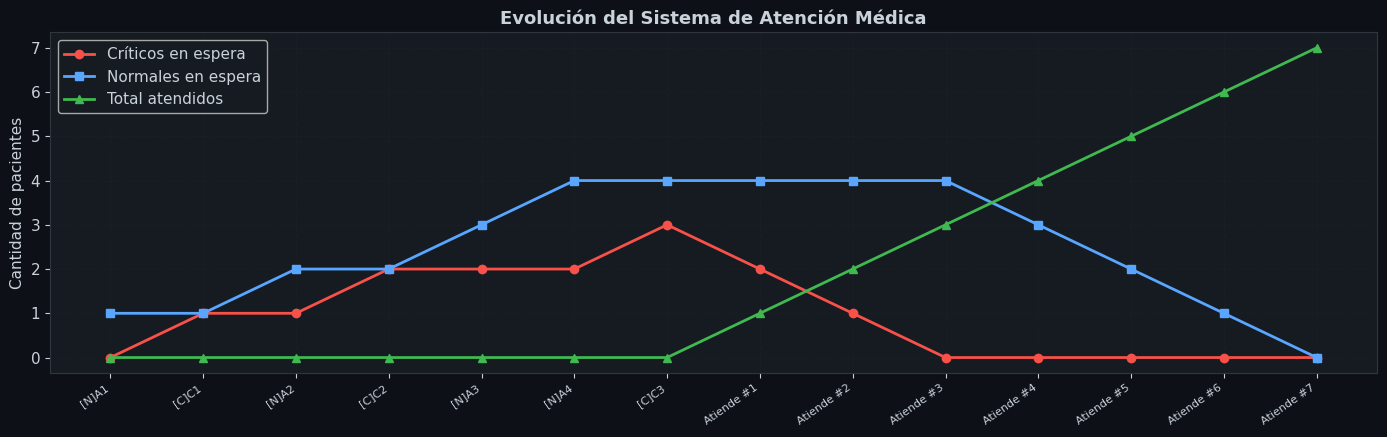

In [10]:
# ── Gráfica de evolución del sistema ─────────────────────────────────────────
def simular_y_graficar():
    s = SistemaAtencionMedica()
    secuencia = [
        ('N','A1'),('C','C1'),('N','A2'),('C','C2'),
        ('N','A3'),('N','A4'),('C','C3'),
    ]
    snap_crit, snap_norm, snap_at, etiquetas = [], [], [], []

    for tipo, nom in secuencia:
        s.agregar_paciente(tipo, nom)
        e = s.estado()
        snap_crit.append(e['criticos_espera'])
        snap_norm.append(e['normales_espera'])
        snap_at.append(e['total_atendidos'])
        etiquetas.append(f'[{tipo}]{nom}')

    # Ahora atender uno a uno
    for i in range(len(secuencia)):
        s.atender_paciente()
        e = s.estado()
        snap_crit.append(e['criticos_espera'])
        snap_norm.append(e['normales_espera'])
        snap_at.append(e['total_atendidos'])
        etiquetas.append(f'Atiende #{i+1}')

    x = range(len(etiquetas))
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.plot(x, snap_crit, 'o-', color=RED,    label='Críticos en espera', lw=2)
    ax.plot(x, snap_norm, 's-', color=ACCENT, label='Normales en espera', lw=2)
    ax.plot(x, snap_at,  '^-', color=GREEN,   label='Total atendidos',    lw=2)
    ax.set_xticks(list(x))
    ax.set_xticklabels(etiquetas, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Cantidad de pacientes')
    ax.set_title('Evolución del Sistema de Atención Médica')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

simular_y_graficar()


---
# II. Árboles Binarios de Búsqueda y Árboles AVL
## Semana 8

Un **Árbol Binario de Búsqueda (BST)** organiza datos de forma que, para cada nodo `n`, todos los valores del subárbol izquierdo son menores que `n.v` y todos los del subárbol derecho son mayores. Esta propiedad habilita búsquedas, inserciones y eliminaciones en **O(h)**, donde `h` es la altura del árbol.

---
## 2.1 Implementación Funcional del BST


In [11]:
# ── Nodo como diccionario (sin clases, estilo funcional) ──────────────────────
def nodo(v):
    return {'v': v, 'i': None, 'd': None}

def bst_insertar(raiz, v):
    """Inserta v en el BST. Retorna la nueva raíz. O(h)."""
    if raiz is None:
        return nodo(v)
    if v < raiz['v']:
        raiz['i'] = bst_insertar(raiz['i'], v)
    elif v > raiz['v']:
        raiz['d'] = bst_insertar(raiz['d'], v)
    return raiz

def bst_buscar(raiz, v):
    """Busca v en el BST. Retorna True/False. O(h)."""
    if raiz is None:
        return False
    if v == raiz['v']:
        return True
    return bst_buscar(raiz['i'], v) if v < raiz['v'] else bst_buscar(raiz['d'], v)

def obtener_minimo(raiz):
    """Retorna el nodo con valor mínimo. O(h)."""
    while raiz and raiz['i']:
        raiz = raiz['i']
    return raiz

def bst_eliminar(raiz, v):
    """Elimina v del BST (reemplazo por sucesor in-order). O(h)."""
    if raiz is None:
        return None
    if v < raiz['v']:
        raiz['i'] = bst_eliminar(raiz['i'], v)
    elif v > raiz['v']:
        raiz['d'] = bst_eliminar(raiz['d'], v)
    else:
        # Caso 1: sin hijos
        if raiz['i'] is None and raiz['d'] is None:
            return None
        # Caso 2: un hijo
        if raiz['i'] is None:
            return raiz['d']
        if raiz['d'] is None:
            return raiz['i']
        # Caso 3: dos hijos → reemplazar con sucesor in-order
        sucesor = obtener_minimo(raiz['d'])
        raiz['v'] = sucesor['v']
        raiz['d'] = bst_eliminar(raiz['d'], sucesor['v'])
    return raiz

# ── Recorridos ────────────────────────────────────────────────────────────────
def inorden(raiz):
    """Recorre izq → raíz → der. Produce valores en orden ascendente."""
    return (inorden(raiz['i']) + [raiz['v']] + inorden(raiz['d'])) if raiz else []

def preorden(raiz):
    """Recorre raíz → izq → der. Útil para serializar el árbol."""
    return ([raiz['v']] + preorden(raiz['i']) + preorden(raiz['d'])) if raiz else []

def postorden(raiz):
    """Recorre izq → der → raíz. Útil para liberar memoria o evaluar expresiones."""
    return (postorden(raiz['i']) + postorden(raiz['d']) + [raiz['v']]) if raiz else []

def altura(raiz):
    """Altura del árbol: -1 para árbol vacío, 0 para nodo hoja. O(n)."""
    if raiz is None:
        return -1
    return 1 + max(altura(raiz['i']), altura(raiz['d']))

# ── Construcción ──────────────────────────────────────────────────────────────
valores = [50, 30, 70, 20, 40, 60, 80, 10, 35, 55]
bst = None
for v in valores:
    bst = bst_insertar(bst, v)

print("Valores insertados:", valores)
print("Inorden  (ascend.):", inorden(bst))
print("Preorden (raíz 1°):", preorden(bst))
print("Postorden(raíz últ):", postorden(bst))
print("Altura del árbol:  ", altura(bst))
print("Buscar 40:", bst_buscar(bst, 40), "| Buscar 99:", bst_buscar(bst, 99))


Valores insertados: [50, 30, 70, 20, 40, 60, 80, 10, 35, 55]
Inorden  (ascend.): [10, 20, 30, 35, 40, 50, 55, 60, 70, 80]
Preorden (raíz 1°): [50, 30, 20, 10, 40, 35, 70, 60, 55, 80]
Postorden(raíz últ): [10, 20, 35, 40, 30, 55, 60, 80, 70, 50]
Altura del árbol:   3
Buscar 40: True | Buscar 99: False


---
## 2.2 Visualización del BST

La representación gráfica de un BST facilita la comprensión de su estructura interna. Se utiliza un algoritmo de posicionamiento recursivo que asigna coordenadas x/y a cada nodo según su profundidad y su rango horizontal en el árbol.


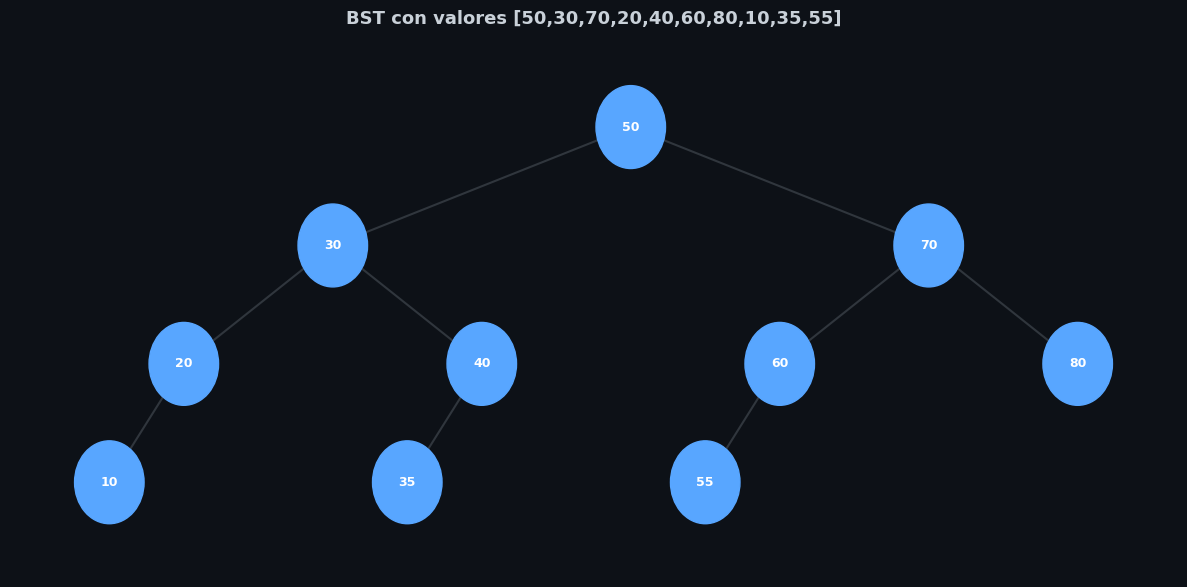

In [12]:
def _posiciones_bst(raiz, x=0.0, y=0.0, dx=1.0, pos=None, aristas=None):
    """Calcula posiciones (x,y) de cada nodo para visualización."""
    if pos is None:   pos = {}
    if aristas is None: aristas = []
    if raiz is None:  return pos, aristas
    pos[id(raiz)] = (x, y, raiz['v'])
    if raiz['i']:
        aristas.append((x, y, x - dx, y - 1.0))
        _posiciones_bst(raiz['i'], x - dx, y - 1.0, dx / 2, pos, aristas)
    if raiz['d']:
        aristas.append((x, y, x + dx, y - 1.0))
        _posiciones_bst(raiz['d'], x + dx, y - 1.0, dx / 2, pos, aristas)
    return pos, aristas

def dibujar_bst(raiz, titulo='Árbol Binario de Búsqueda'):
    pos, aristas = _posiciones_bst(raiz, dx=3.0)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(titulo); ax.axis('off')
    for (x0, y0, x1, y1) in aristas:
        ax.plot([x0, x1], [y0, y1], '-', color='#30363d', lw=1.5, zorder=1)
    for nid, (x, y, v) in pos.items():
        circ = plt.Circle((x, y), 0.35, color=ACCENT, zorder=2)
        ax.add_patch(circ)
        ax.text(x, y, str(v), ha='center', va='center',
                fontsize=9, color='white', fontweight='bold', zorder=3)
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    if xs:
        ax.set_xlim(min(xs)-1, max(xs)+1)
        ax.set_ylim(min(ys)-0.8, max(ys)+0.8)
    plt.tight_layout(); plt.show()

dibujar_bst(bst, título := 'BST con valores [50,30,70,20,40,60,80,10,35,55]')


---
## 2.3 Análisis de Forma del BST

La **forma** de un BST es determinante para su rendimiento. Un árbol perfectamente balanceado tiene altura `⌊log₂ n⌋`, pero inserciones ordenadas producen un árbol degenerado con altura `n-1`.


In [13]:
def analizar_forma_bst(raiz):
    """
    Analiza la forma del árbol:
      - Compara altura con log2(n).
      - Clasifica: balanceado / inclinado izquierda / inclinado derecha.
    """
    def contar(r):
        if r is None: return 0
        return 1 + contar(r['i']) + contar(r['d'])

    n   = contar(raiz)
    h   = altura(raiz)
    opt = math.floor(math.log2(n)) if n > 0 else 0
    hi  = altura(raiz['i']) if raiz else -1
    hd  = altura(raiz['d']) if raiz else -1
    bal = hi - hd

    forma = 'balanceado' if abs(bal) <= 1 else             ('inclinado a la izquierda' if bal > 1 else 'inclinado a la derecha')

    return {
        'n_nodos': n, 'altura_real': h,
        'altura_optima': opt,
        'factor_balance': bal, 'forma': forma,
        'eficiencia': f'{(opt/h*100):.1f}%' if h > 0 else '100%',
    }

info = analizar_forma_bst(bst)
for k, v in info.items():
    print(f"  {k:<20}: {v}")

# ── Caso degenerado ───────────────────────────────────────────────────────────
print()
bst_deg = None
for v in range(1, 11):
    bst_deg = bst_insertar(bst_deg, v)
info_deg = analizar_forma_bst(bst_deg)
print("BST degenerado (inserciones 1–10):")
for k, v in info_deg.items():
    print(f"  {k:<20}: {v}")


  n_nodos             : 10
  altura_real         : 3
  altura_optima       : 3
  factor_balance      : 0
  forma               : balanceado
  eficiencia          : 100.0%

BST degenerado (inserciones 1–10):
  n_nodos             : 10
  altura_real         : 9
  altura_optima       : 3
  factor_balance      : -9
  forma               : inclinado a la derecha
  eficiencia          : 33.3%


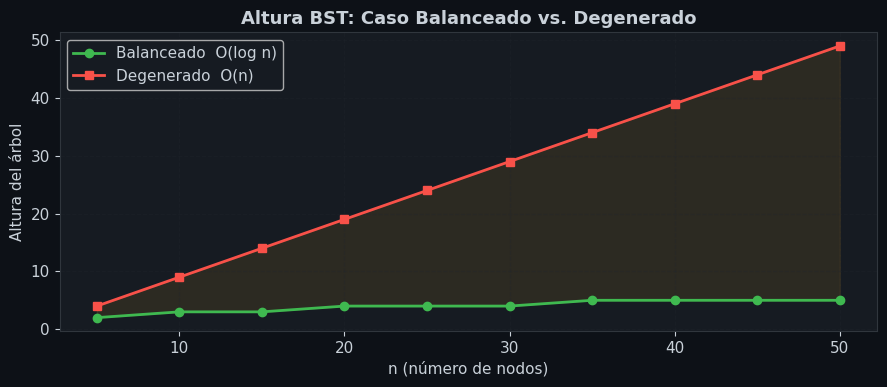

In [14]:
# ── Gráfica comparativa: altura real vs. óptima ───────────────────────────────
ns = list(range(5, 51, 5))
alt_bal = [math.floor(math.log2(n)) for n in ns]
alt_deg = [n - 1 for n in ns]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ns, alt_bal, 'o-', color=GREEN,  label='Balanceado  O(log n)', lw=2)
ax.plot(ns, alt_deg, 's-', color=RED,    label='Degenerado  O(n)',     lw=2)
ax.fill_between(ns, alt_bal, alt_deg, alpha=0.12, color=ORANGE)
ax.set_xlabel('n (número de nodos)')
ax.set_ylabel('Altura del árbol')
ax.set_title('Altura BST: Caso Balanceado vs. Degenerado')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## 2.4 Árbol AVL — Autobalanceo mediante Rotaciones

El **Árbol AVL** (*Adelson-Velsky y Landis*, 1962) garantiza que el factor de balance de cada nodo (`|altura(izq) − altura(der)|`) no exceda 1. Cuando una inserción viola esta condición, se aplica una de cuatro rotaciones:

| Caso | Condición | Rotación |
|------|-----------|----------|
| LL   | balance > 1 y nuevo_val < hijo_izq | Rotación derecha simple |
| RR   | balance < -1 y nuevo_val > hijo_der | Rotación izquierda simple |
| LR   | balance > 1 y nuevo_val > hijo_izq | Rot. izq. en hijo_izq, luego rot. der. |
| RL   | balance < -1 y nuevo_val < hijo_der | Rot. der. en hijo_der, luego rot. izq. |


In [15]:
def nodo_avl(v):
    return {'v': v, 'i': None, 'd': None, 'h': 1}

def _h(n):   return n['h'] if n else 0
def _bal(n): return (_h(n['i']) - _h(n['d'])) if n else 0
def _upd(n): n['h'] = 1 + max(_h(n['i']), _h(n['d']))

def rot_derecha(y):
    """Rotación simple derecha (caso LL)."""
    x, T2 = y['i'], y['i']['d']
    x['d'] = y; y['i'] = T2
    _upd(y); _upd(x)
    return x

def rot_izquierda(x):
    """Rotación simple izquierda (caso RR)."""
    y, T2 = x['d'], x['d']['i']
    y['i'] = x; x['d'] = T2
    _upd(x); _upd(y)
    return y

def avl_insertar(raiz, v):
    """Inserta v en el AVL con rebalanceo automático. O(log n)."""
    if raiz is None:
        return nodo_avl(v)
    if v < raiz['v']:
        raiz['i'] = avl_insertar(raiz['i'], v)
    elif v > raiz['v']:
        raiz['d'] = avl_insertar(raiz['d'], v)
    else:
        return raiz  # Duplicado ignorado

    _upd(raiz)
    bal = _bal(raiz)

    if bal > 1 and v < raiz['i']['v']:          # LL
        return rot_derecha(raiz)
    if bal < -1 and v > raiz['d']['v']:         # RR
        return rot_izquierda(raiz)
    if bal > 1 and v > raiz['i']['v']:          # LR
        raiz['i'] = rot_izquierda(raiz['i'])
        return rot_derecha(raiz)
    if bal < -1 and v < raiz['d']['v']:         # RL
        raiz['d'] = rot_derecha(raiz['d'])
        return rot_izquierda(raiz)

    return raiz

def inorden_avl(raiz):
    return (inorden_avl(raiz['i']) + [raiz['v']] + inorden_avl(raiz['d'])) if raiz else []

def altura_avl(raiz):
    return raiz['h'] - 1 if raiz else -1

# ── Demo: secuencia que dispara todos los casos de rotación ───────────────────
avl = None
seq = [10, 20, 30, 40, 50, 25]   # RR, LL, RL …
print("Inserción paso a paso en AVL:")
for v in seq:
    avl = avl_insertar(avl, v)
    print(f"  insert({v:2d}) → inorden={inorden_avl(avl)}, altura={altura_avl(avl)}")


Inserción paso a paso en AVL:
  insert(10) → inorden=[10], altura=0
  insert(20) → inorden=[10, 20], altura=1
  insert(30) → inorden=[10, 20, 30], altura=1
  insert(40) → inorden=[10, 20, 30, 40], altura=2
  insert(50) → inorden=[10, 20, 30, 40, 50], altura=2
  insert(25) → inorden=[10, 20, 25, 30, 40, 50], altura=2


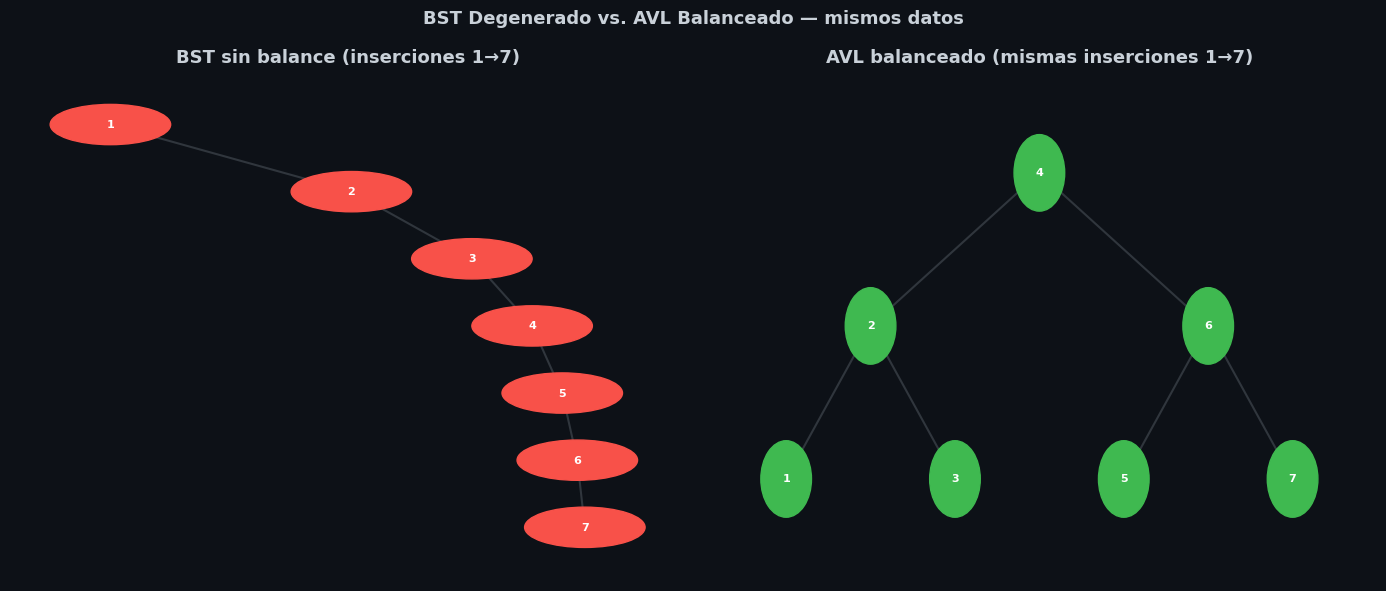

In [16]:
def _pos_avl(raiz, x=0.0, y=0.0, dx=1.5, pos=None, aristas=None):
    if pos is None:   pos = {}
    if aristas is None: aristas = []
    if raiz is None:  return pos, aristas
    pos[id(raiz)] = (x, y, raiz['v'], _bal(raiz))
    if raiz['i']:
        aristas.append((x, y, x - dx, y - 1.2))
        _pos_avl(raiz['i'], x - dx, y - 1.2, dx / 2, pos, aristas)
    if raiz['d']:
        aristas.append((x, y, x + dx, y - 1.2))
        _pos_avl(raiz['d'], x + dx, y - 1.2, dx / 2, pos, aristas)
    return pos, aristas

def dibujar_avl(raiz, titulo='Árbol AVL'):
    pos, aristas = _pos_avl(raiz, dx=2.5)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title(titulo); ax.axis('off')
    for (x0, y0, x1, y1) in aristas:
        ax.plot([x0, x1], [y0, y1], '-', color='#30363d', lw=1.5, zorder=1)
    for nid, (x, y, v, b) in pos.items():
        col = GREEN if abs(b) <= 1 else RED
        circ = plt.Circle((x, y), 0.40, color=col, zorder=2)
        ax.add_patch(circ)
        ax.text(x, y + 0.08, str(v), ha='center', va='center',
                fontsize=9, color='white', fontweight='bold', zorder=3)
        ax.text(x, y - 0.16, f'b={b}', ha='center', va='center',
                fontsize=7, color='#aaa', zorder=3)
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    if xs:
        ax.set_xlim(min(xs)-1, max(xs)+1)
        ax.set_ylim(min(ys)-0.8, max(ys)+0.8)
    legend = [
        mpatches.Patch(color=GREEN, label='Balanceado |b|≤1'),
        mpatches.Patch(color=RED,   label='Desbalanceado |b|>1'),
    ]
    ax.legend(handles=legend, loc='upper right')
    plt.tight_layout(); plt.show()

# Árbol antes de auto-balance (BST degenerado 1..7)
bst_d = None
for v in [1,2,3,4,5,6,7]:
    bst_d = bst_insertar(bst_d, v)

avl_d = None
for v in [1,2,3,4,5,6,7]:
    avl_d = avl_insertar(avl_d, v)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax_t in axes: ax_t.axis('off')

# Dibujar BST degenerado en axes[0]
pos_b, aristas_b = _posiciones_bst(bst_d, dx=1.2)
axes[0].set_title('BST sin balance (inserciones 1→7)')
for (x0,y0,x1,y1) in aristas_b:
    axes[0].plot([x0,x1],[y0,y1],'-',color='#30363d',lw=1.5,zorder=1)
for nid,(x,y,v) in pos_b.items():
    axes[0].add_patch(plt.Circle((x,y),0.30,color=RED,zorder=2))
    axes[0].text(x,y,str(v),ha='center',va='center',fontsize=8,color='white',fontweight='bold',zorder=3)
xs=[p[0] for p in pos_b.values()]; ys=[p[1] for p in pos_b.values()]
axes[0].set_xlim(min(xs)-0.5,max(xs)+0.5); axes[0].set_ylim(min(ys)-0.8,max(ys)+0.8)

# Dibujar AVL en axes[1]
pos_a, aristas_a = _pos_avl(avl_d, dx=2.0)
axes[1].set_title('AVL balanceado (mismas inserciones 1→7)')
for (x0,y0,x1,y1) in aristas_a:
    axes[1].plot([x0,x1],[y0,y1],'-',color='#30363d',lw=1.5,zorder=1)
for nid,(x,y,v,b) in pos_a.items():
    axes[1].add_patch(plt.Circle((x,y),0.30,color=GREEN,zorder=2))
    axes[1].text(x,y,str(v),ha='center',va='center',fontsize=8,color='white',fontweight='bold',zorder=3)
xs=[p[0] for p in pos_a.values()]; ys=[p[1] for p in pos_a.values()]
axes[1].set_xlim(min(xs)-1,max(xs)+1); axes[1].set_ylim(min(ys)-0.8,max(ys)+0.8)

plt.suptitle('BST Degenerado vs. AVL Balanceado — mismos datos', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 2.5 Sistema de Inventario de Computadores con BST y AVL

La aplicación concreta de los árboles BST y AVL en este módulo fue el **Inventario de Computadores**: cada computador se identifica por un código numérico que actúa como clave del árbol. Esto permite búsquedas en O(log n) y recorridos ordenados sin necesidad de algoritmos de ordenamiento adicionales.


In [17]:
inventario_datos = [
    (50, 'Laptop HP'),   (30, 'PC Dell'),   (70, 'Laptop Lenovo'),
    (20, 'PC Acer'),     (40, 'Tablet Samsung'), (60, 'PC Asus'),
    (80, 'Workstation'),
]

# ── BST ───────────────────────────────────────────────────────────────────────
def nodo_inv(codigo, nombre):
    return {'v': codigo, 'nombre': nombre, 'i': None, 'd': None}

def inv_insertar(raiz, codigo, nombre):
    if raiz is None:
        return nodo_inv(codigo, nombre)
    if codigo < raiz['v']:
        raiz['i'] = inv_insertar(raiz['i'], codigo, nombre)
    elif codigo > raiz['v']:
        raiz['d'] = inv_insertar(raiz['d'], codigo, nombre)
    return raiz

def inv_buscar(raiz, codigo):
    if raiz is None:
        return None
    if codigo == raiz['v']:
        return raiz['nombre']
    return inv_buscar(raiz['i'], codigo) if codigo < raiz['v'] else inv_buscar(raiz['d'], codigo)

def inv_inorden(raiz):
    return (inv_inorden(raiz['i']) + [(raiz['v'], raiz['nombre'])] + inv_inorden(raiz['d'])) if raiz else []

inv_bst = None
for cod, nom in inventario_datos:
    inv_bst = inv_insertar(inv_bst, cod, nom)

print("Inventario en orden ascendente de código:")
for cod, nom in inv_inorden(inv_bst):
    print(f"  Código {cod:3d} → {nom}")

print()
for buscar_cod in [40, 99, 80]:
    res = inv_buscar(inv_bst, buscar_cod)
    print(f"  Buscar código {buscar_cod}: {'Encontrado — ' + res if res else 'No encontrado'}")


Inventario en orden ascendente de código:
  Código  20 → PC Acer
  Código  30 → PC Dell
  Código  40 → Tablet Samsung
  Código  50 → Laptop HP
  Código  60 → PC Asus
  Código  70 → Laptop Lenovo
  Código  80 → Workstation

  Buscar código 40: Encontrado — Tablet Samsung
  Buscar código 99: No encontrado
  Buscar código 80: Encontrado — Workstation


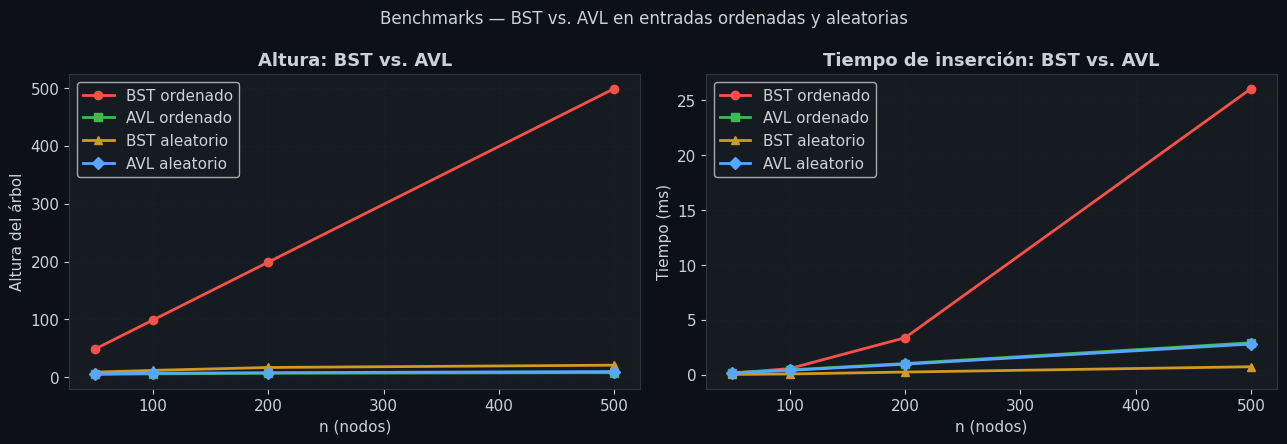

In [18]:
# ── Comparación de rendimiento: BST vs AVL ────────────────────────────────────
import timeit

def benchmark(n, ordenado=False):
    vals = list(range(1, n+1)) if ordenado else random.sample(range(1, n*10+1), n)
    
    def ins_bst():
        r = None
        for v in vals: r = bst_insertar(r, v)
        return r
    def ins_avl():
        r = None
        for v in vals: r = avl_insertar(r, v)
        return r
    
    t_bst = timeit.timeit(ins_bst, number=5) / 5
    t_avl = timeit.timeit(ins_avl, number=5) / 5
    
    r_bst = ins_bst()
    r_avl = ins_avl()
    return t_bst, t_avl, altura(r_bst), altura_avl(r_avl)

ns = [50, 100, 200, 500]
t_bst_ord, t_avl_ord, h_bst_ord, h_avl_ord = [], [], [], []
t_bst_rnd, t_avl_rnd, h_bst_rnd, h_avl_rnd = [], [], [], []

for n in ns:
    tb, ta, hb, ha = benchmark(n, ordenado=True)
    t_bst_ord.append(tb * 1000); t_avl_ord.append(ta * 1000)
    h_bst_ord.append(hb); h_avl_ord.append(ha)
    
    tb, ta, hb, ha = benchmark(n, ordenado=False)
    t_bst_rnd.append(tb * 1000); t_avl_rnd.append(ta * 1000)
    h_bst_rnd.append(hb); h_avl_rnd.append(ha)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(ns, h_bst_ord, 'o-', color=RED,    label='BST ordenado',    lw=2)
ax1.plot(ns, h_avl_ord, 's-', color=GREEN,  label='AVL ordenado',    lw=2)
ax1.plot(ns, h_bst_rnd, '^-', color=ORANGE, label='BST aleatorio',   lw=2)
ax1.plot(ns, h_avl_rnd, 'D-', color=ACCENT, label='AVL aleatorio',   lw=2)
ax1.set_xlabel('n (nodos)'); ax1.set_ylabel('Altura del árbol')
ax1.set_title('Altura: BST vs. AVL'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ns, t_bst_ord, 'o-', color=RED,    label='BST ordenado',  lw=2)
ax2.plot(ns, t_avl_ord, 's-', color=GREEN,  label='AVL ordenado',  lw=2)
ax2.plot(ns, t_bst_rnd, '^-', color=ORANGE, label='BST aleatorio', lw=2)
ax2.plot(ns, t_avl_rnd, 'D-', color=ACCENT, label='AVL aleatorio', lw=2)
ax2.set_xlabel('n (nodos)'); ax2.set_ylabel('Tiempo (ms)')
ax2.set_title('Tiempo de inserción: BST vs. AVL'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Benchmarks — BST vs. AVL en entradas ordenadas y aleatorias', fontsize=12)
plt.tight_layout(); plt.show()


---
# III. Árboles BST Avanzados y Teoría de Grafos
## Semana 9

La semana 9 extiende el trabajo sobre BST con tres algoritmos clásicos —cálculo de altura, validación y ancestro común más bajo— y expande el dominio hacia los **grafos**, estructuras que modelan redes de relaciones arbitrarias.

---
## 3.1 Altura del Árbol Binario

El cálculo de la altura sigue el paradigma **divide y vencerás**: la altura de un árbol es `1 + max(altura(izq), altura(der))`. El caso base establece que un árbol vacío tiene altura `-1` (convención HackerRank).


In [19]:
def height(root):
    """
    Calcula la altura del árbol binario.
    Complejidad: O(n) tiempo · O(h) espacio en pila de llamadas.
    Convenio: altura(None) = -1, altura(hoja) = 0.
    """
    if root is None:
        return -1
    return 1 + max(height(root['i']), height(root['d']))

# Demostración con árboles de distintas formas
def build_bst(*vals):
    r = None
    for v in vals: r = bst_insertar(r, v)
    return r

arbs = {
    'Balanceado [4,2,6,1,3,5,7]':  build_bst(4,2,6,1,3,5,7),
    'Lineal izq  [5,4,3,2,1]':     build_bst(5,4,3,2,1),
    'Lineal der  [1,2,3,4,5]':     build_bst(1,2,3,4,5),
    'Un solo nodo [42]':            build_bst(42),
}
for desc, arb in arbs.items():
    n = len(inorden(arb))
    h = height(arb)
    opt = math.floor(math.log2(n)) if n > 1 else 0
    print(f"  {desc:<35}  n={n}  h={h}  h_óptima={opt}")


  Balanceado [4,2,6,1,3,5,7]           n=7  h=2  h_óptima=2
  Lineal izq  [5,4,3,2,1]              n=5  h=4  h_óptima=2
  Lineal der  [1,2,3,4,5]              n=5  h=4  h_óptima=2
  Un solo nodo [42]                    n=1  h=0  h_óptima=0


---
## 3.2 Validación de Árbol BST

Un árbol es un BST válido si y solo si **para cada nodo**, su valor se halla estrictamente dentro del rango `(min_permitido, max_permitido)` determinado por sus ancestros. La función propagates límites hacia los subárboles izquierdo y derecho.


In [20]:
def es_bst_valido(raiz, min_val=float('-inf'), max_val=float('inf')):
    """
    Valida si el árbol es un BST correcto mediante propagación de límites.
    O(n) tiempo · O(h) espacio.
    """
    if raiz is None:
        return True
    if not (min_val < raiz['v'] < max_val):
        return False
    return (es_bst_valido(raiz['i'], min_val, raiz['v']) and
            es_bst_valido(raiz['d'], raiz['v'], max_val))

# ── Casos de prueba ───────────────────────────────────────────────────────────
bst_valido = build_bst(50, 30, 70, 20, 40)

# Árbol inválido: violar propiedad (nodo 45 en subárbol izquierdo con valor > padre 50)
def construir_invalido():
    raiz = nodo(50)
    raiz['i'] = nodo(30)
    raiz['d'] = nodo(70)
    raiz['i']['d'] = nodo(45)
    raiz['i']['d']['d'] = nodo(55)  # 55 > 50 pero está en subárbol izq ← INVÁLIDO
    return raiz

invalido = construir_invalido()
print("BST construido con bst_insertar — válido:", es_bst_valido(bst_valido))
print("Árbol con violación de propiedad  — válido:", es_bst_valido(invalido))


BST construido con bst_insertar — válido: True
Árbol con violación de propiedad  — válido: False


---
## 3.3 Ancestro Común Más Bajo (LCA) en BST

El **Ancestro Común Más Bajo** (*Lowest Common Ancestor*) de dos nodos `v1` y `v2` es el nodo más profundo que tiene a ambos como descendientes. En un BST, la propiedad de orden permite un algoritmo iterativo en **O(h)** sin necesidad de recorrer todo el árbol: el LCA es el primer nodo donde los caminos hacia `v1` y `v2` se separan.


In [21]:
def lca(raiz, v1, v2):
    """
    LCA iterativo en BST. O(h) tiempo · O(1) espacio.
    Precondición: v1 y v2 existen en el árbol.
    """
    if v1 > v2:
        v1, v2 = v2, v1    # Asegurar v1 ≤ v2

    nodo_actual = raiz
    while nodo_actual:
        if nodo_actual['v'] < v1:
            nodo_actual = nodo_actual['d']   # Ambos a la derecha
        elif nodo_actual['v'] > v2:
            nodo_actual = nodo_actual['i']   # Ambos a la izquierda
        else:
            return nodo_actual['v']          # v1 ≤ actual ≤ v2  → LCA encontrado
    return None

# ── Demostración ──────────────────────────────────────────────────────────────
arb_lca = build_bst(20, 10, 30, 5, 15, 25, 35, 3, 7, 12, 18)
pares = [(5, 35), (5, 15), (25, 35), (3, 7), (12, 18), (5, 18)]
for v1, v2 in pares:
    print(f"  LCA({v1:2d}, {v2:2d}) = {lca(arb_lca, v1, v2)}")


  LCA( 5, 35) = 20
  LCA( 5, 15) = 10
  LCA(25, 35) = 30
  LCA( 3,  7) = 5
  LCA(12, 18) = 15
  LCA( 5, 18) = 10


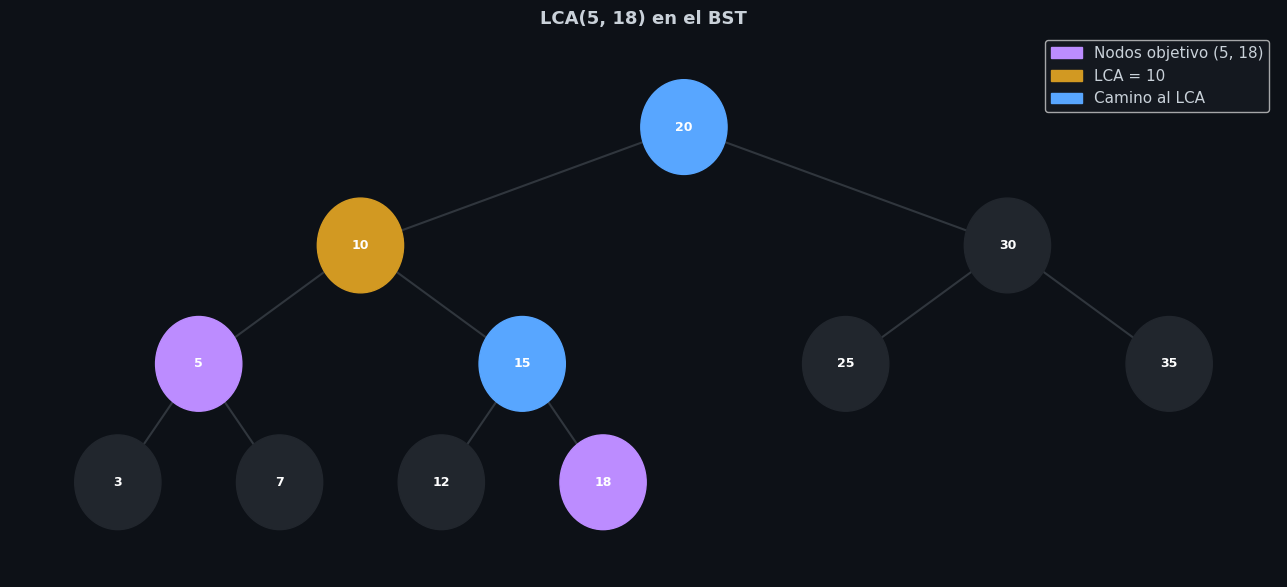

In [22]:
def visualizar_lca(raiz, v1, v2, titulo='LCA en BST'):
    """Dibuja el BST destacando el camino al LCA."""
    lca_val = lca(raiz, v1, v2)

    def ruta(r, objetivo, camino=None):
        if camino is None: camino = []
        if r is None: return None
        camino.append(r['v'])
        if r['v'] == objetivo: return camino[:]
        if objetivo < r['v']:
            return ruta(r['i'], objetivo, camino)
        else:
            return ruta(r['d'], objetivo, camino)

    ruta1 = set(ruta(raiz, v1) or [])
    ruta2 = set(ruta(raiz, v2) or [])
    en_ruta = ruta1 | ruta2

    pos, aristas = _posiciones_bst(raiz, dx=3.0)
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.set_title(titulo); ax.axis('off')

    for (x0, y0, x1, y1) in aristas:
        ax.plot([x0, x1], [y0, y1], '-', color='#30363d', lw=1.5, zorder=1)

    for nid, (x, y, v) in pos.items():
        if v == lca_val:
            col = ORANGE
        elif v == v1 or v == v2:
            col = PURPLE
        elif v in en_ruta:
            col = ACCENT
        else:
            col = '#21262d'
        circ = plt.Circle((x, y), 0.40, color=col, zorder=2)
        ax.add_patch(circ)
        ax.text(x, y, str(v), ha='center', va='center',
                fontsize=9, color='white', fontweight='bold', zorder=3)

    xs=[p[0] for p in pos.values()]; ys=[p[1] for p in pos.values()]
    ax.set_xlim(min(xs)-1, max(xs)+1); ax.set_ylim(min(ys)-0.8, max(ys)+0.8)
    legend = [
        mpatches.Patch(color=PURPLE, label=f'Nodos objetivo ({v1}, {v2})'),
        mpatches.Patch(color=ORANGE, label=f'LCA = {lca_val}'),
        mpatches.Patch(color=ACCENT, label='Camino al LCA'),
    ]
    ax.legend(handles=legend, loc='upper right')
    plt.tight_layout(); plt.show()

visualizar_lca(arb_lca, 5, 18, titulo=f'LCA(5, 18) en el BST')


---
## 3.4 Teoría de Grafos — Fundamentos

Un **grafo** `G = (V, E)` es un par donde `V` es el conjunto de vértices y `E` el de aristas. Existen múltiples formas de representar un grafo en memoria:

| Representación | Espacio | Consulta `(u,v)?` | Vecinos de `u` |
|----------------|---------|-------------------|----------------|
| Matriz de adyacencia | O(V²) | O(1) | O(V) |
| Lista de adyacencia | O(V+E) | O(grado(u)) | O(grado(u)) |

Para grafos dispersos (E ≪ V²), la **lista de adyacencia** es la representación preferida, como se implementó en el laboratorio de distribución de almacenes.

---
## 3.5 Implementación del Grafo de Distribución

El problema modela **8 almacenes** (A–H) conectados por rutas bidireccionales. Las conexiones representan disponibilidad de transporte entre almacenes adyacentes.


In [23]:
def crear_grafo():
    """Retorna un grafo vacío (dict de listas de adyacencia)."""
    return {}

def agregar_vertice(grafo, v):
    """O(1) — añade vértice sin aristas."""
    if v not in grafo:
        grafo[v] = []

def agregar_arista(grafo, u, v):
    """O(1) — arista bidireccional."""
    agregar_vertice(grafo, u)
    agregar_vertice(grafo, v)
    if v not in grafo[u]: grafo[u].append(v)
    if u not in grafo[v]: grafo[v].append(u)

def imprimir_grafo(grafo):
    """Imprime la lista de adyacencia."""
    for v in sorted(grafo):
        print(f"  {v}: {sorted(grafo[v])}")

def matriz_adyacencia(grafo):
    """Retorna la matriz como dict de dicts."""
    verts = sorted(grafo.keys())
    mat = {u: {v: 0 for v in verts} for u in verts}
    for u in grafo:
        for v in grafo[u]:
            mat[u][v] = 1
    return mat, verts

# ── Construcción del grafo de almacenes ──────────────────────────────────────
g = crear_grafo()
aristas = [
    ('A','B'), ('A','C'), ('B','D'), ('B','E'),
    ('C','F'), ('C','G'), ('D','H'), ('E','F'), ('G','H'),
]
for u, v in aristas:
    agregar_arista(g, u, v)

print("Lista de adyacencia:")
imprimir_grafo(g)

print()
mat, verts = matriz_adyacencia(g)
header = '   ' + ' '.join(f'{v:2s}' for v in verts)
print("Matriz de adyacencia:")
print(header)
for u in verts:
    fila = ' '.join(str(mat[u][v]) + ' ' for v in verts)
    print(f"  {u}: {fila}")


Lista de adyacencia:
  A: ['B', 'C']
  B: ['A', 'D', 'E']
  C: ['A', 'F', 'G']
  D: ['B', 'H']
  E: ['B', 'F']
  F: ['C', 'E']
  G: ['C', 'H']
  H: ['D', 'G']

Matriz de adyacencia:
   A  B  C  D  E  F  G  H 
  A: 0  1  1  0  0  0  0  0 
  B: 1  0  0  1  1  0  0  0 
  C: 1  0  0  0  0  1  1  0 
  D: 0  1  0  0  0  0  0  1 
  E: 0  1  0  0  0  1  0  0 
  F: 0  0  1  0  1  0  0  0 
  G: 0  0  1  0  0  0  0  1 
  H: 0  0  0  1  0  0  1  0 


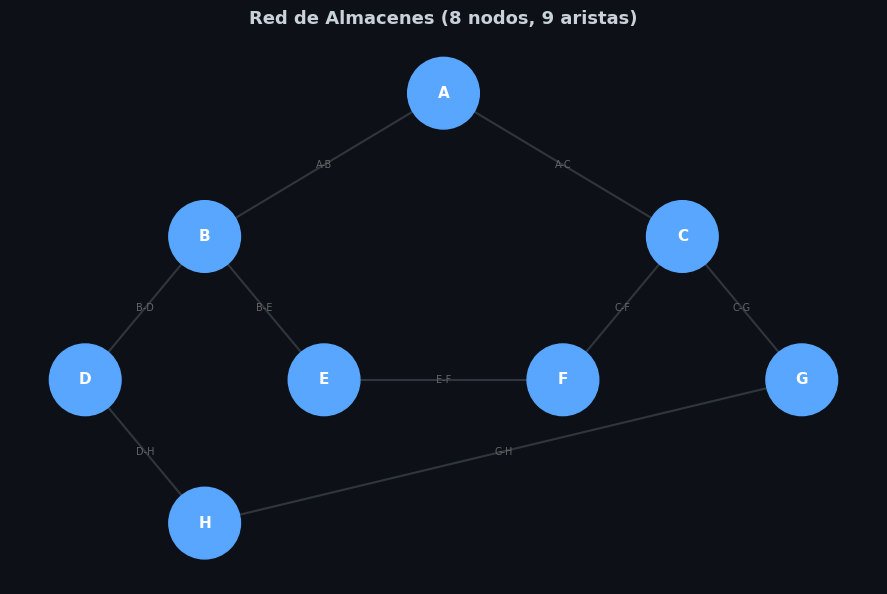

In [24]:
# ── Visualización del grafo ───────────────────────────────────────────────────
def dibujar_grafo(grafo, posiciones, titulo='Grafo', resaltar_aristas=None, visitados=None):
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_title(titulo); ax.axis('off')
    ax.set_aspect('equal')

    trazadas = set()
    for u in grafo:
        xu, yu = posiciones[u]
        for v in grafo[u]:
            key = tuple(sorted([u, v]))
            if key in trazadas: continue
            trazadas.add(key)
            xv, yv = posiciones[v]
            es_res = resaltar_aristas and (key in resaltar_aristas or (v,u) in resaltar_aristas)
            color = GREEN if es_res else '#30363d'
            lw    = 3.0  if es_res else 1.5
            ax.plot([xu, xv], [yu, yv], '-', color=color, lw=lw, zorder=1)
            mx, my = (xu+xv)/2, (yu+yv)/2
            ax.text(mx, my, f'{u}-{v}', ha='center', va='center',
                    fontsize=7, color='#666', zorder=2)

    for v, (x, y) in posiciones.items():
        vis = visitados and v in visitados
        col = ORANGE if vis else ACCENT
        circ = plt.Circle((x, y), 0.30, color=col, zorder=3)
        ax.add_patch(circ)
        ax.text(x, y, v, ha='center', va='center',
                fontsize=11, color='white', fontweight='bold', zorder=4)

    plt.tight_layout(); plt.show()

# Posiciones en layout manual (aproxima árbol binario)
pos_almacenes = {
    'A': (4.0, 4.0), 'B': (2.0, 2.8), 'C': (6.0, 2.8),
    'D': (1.0, 1.6), 'E': (3.0, 1.6), 'F': (5.0, 1.6), 'G': (7.0, 1.6),
    'H': (2.0, 0.4),
}
dibujar_grafo(g, pos_almacenes, titulo='Red de Almacenes (8 nodos, 9 aristas)')


---
## 3.6 Búsqueda en Anchura (BFS — Breadth-First Search)

BFS explora el grafo **nivel por nivel**, partiendo del vértice origen. Utiliza una **cola** para garantizar que todos los vértices a distancia `d` sean visitados antes de los de distancia `d+1`. Esta propiedad lo convierte en el algoritmo óptimo para encontrar el **camino más corto** en grafos no ponderados.

**Complejidad:** O(V + E)


In [25]:
def bfs(grafo, inicio):
    """
    BFS — exploración nivel por nivel.
    Retorna (orden_visita, distancias, padres).
    O(V+E) tiempo · O(V) espacio.
    """
    visitados = {inicio}
    cola      = deque([inicio])
    orden     = []
    dist      = {inicio: 0}
    padres    = {inicio: None}

    while cola:
        nodo = cola.popleft()
        orden.append(nodo)
        for vecino in sorted(grafo[nodo]):
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)
                dist[vecino]   = dist[nodo] + 1
                padres[vecino] = nodo

    return orden, dist, padres

orden_bfs, dist_bfs, padres_bfs = bfs(g, 'A')
print("Orden BFS desde A:", ' → '.join(orden_bfs))
print()
print("Distancias desde A:")
for v in sorted(dist_bfs):
    print(f"  A → {v}: {dist_bfs[v]} saltos")


Orden BFS desde A: A → B → C → D → E → F → G → H

Distancias desde A:
  A → A: 0 saltos
  A → B: 1 saltos
  A → C: 1 saltos
  A → D: 2 saltos
  A → E: 2 saltos
  A → F: 2 saltos
  A → G: 2 saltos
  A → H: 3 saltos


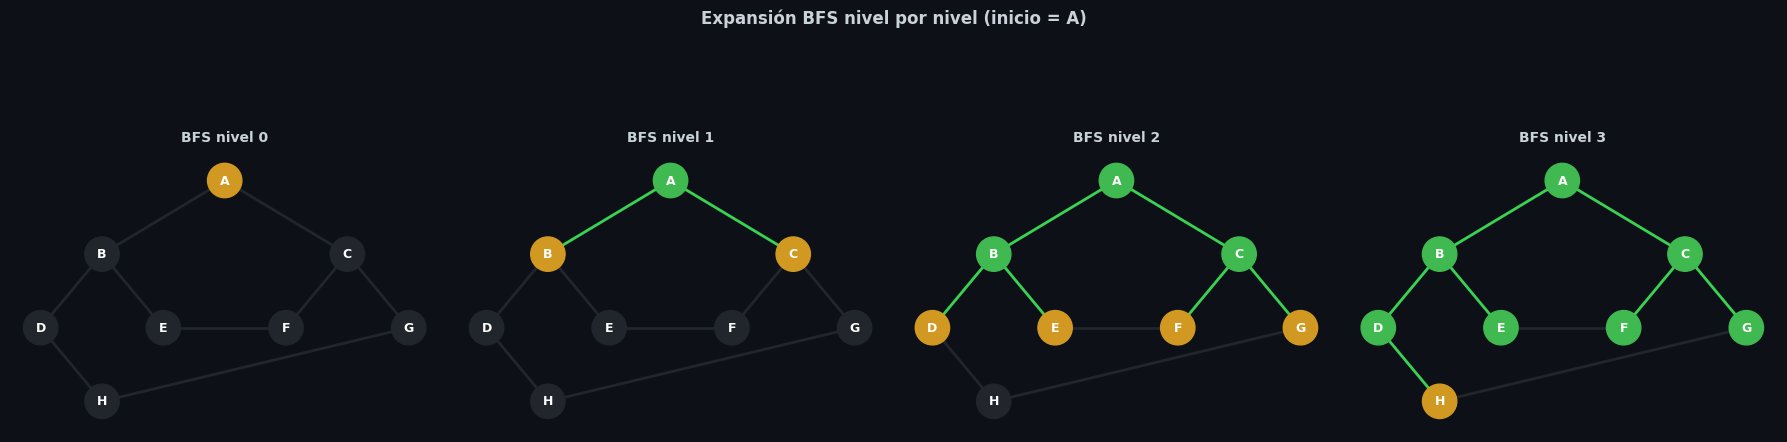

In [26]:
def visualizar_bfs_pasos(grafo, inicio, posiciones):
    """Anima BFS mostrando los 'niveles' de exploración."""
    from collections import defaultdict
    _, dist, padres = bfs(grafo, inicio)

    niveles = defaultdict(list)
    for v, d in dist.items():
        niveles[d].append(v)

    max_nivel = max(dist.values())
    fig, axes = plt.subplots(1, max_nivel + 1,
                             figsize=(4.5 * (max_nivel + 1), 5.5))
    if max_nivel == 0:
        axes = [axes]

    for paso in range(max_nivel + 1):
        ax = axes[paso]
        ax.set_title(f'BFS nivel {paso}', fontsize=10)
        ax.axis('off'); ax.set_aspect('equal')

        visitados_hasta = {v for v, d in dist.items() if d <= paso}
        trazadas = set()
        for u in grafo:
            xu, yu = posiciones[u]
            for v in grafo[u]:
                key = tuple(sorted([u, v]))
                if key in trazadas: continue
                trazadas.add(key)
                xv, yv = posiciones[v]
                en_arbol = (padres.get(v) == u or padres.get(u) == v) and                            u in visitados_hasta and v in visitados_hasta
                col = CYAN if en_arbol else '#21262d'
                ax.plot([xu, xv], [yu, yv], '-', color=col, lw=2, zorder=1)

        for v, (x, y) in posiciones.items():
            d = dist.get(v, 999)
            if d <= paso:
                col = ORANGE if d == paso else GREEN
            else:
                col = '#21262d'
            ax.add_patch(plt.Circle((x, y), 0.28, color=col, zorder=2))
            ax.text(x, y, v, ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold', zorder=3)
        xs=[p[0] for p in posiciones.values()]; ys=[p[1] for p in posiciones.values()]
        ax.set_xlim(min(xs)-0.5, max(xs)+0.5); ax.set_ylim(min(ys)-0.5, max(ys)+0.5)

    plt.suptitle(f'Expansión BFS nivel por nivel (inicio = {inicio})', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

visualizar_bfs_pasos(g, 'A', pos_almacenes)


---
## 3.7 Búsqueda en Profundidad (DFS — Depth-First Search)

DFS explora **tan lejos como sea posible** en cada rama antes de retroceder (*backtracking*). Su implementación recursiva utiliza la **pila de llamadas** implícitamente; la iterativa emplea una pila explícita. DFS es la base de algoritmos de detección de ciclos, componentes fuertemente conexas (Kosaraju, Tarjan) y ordenamiento topológico.

**Complejidad:** O(V + E)


In [27]:
def dfs(grafo, inicio):
    """
    DFS recursivo.
    Retorna (orden_visita, padres, tiempos_entrada, tiempos_salida).
    O(V+E) tiempo · O(V) espacio en pila de llamadas.
    """
    visitados   = set()
    orden       = []
    padres      = {inicio: None}
    t_entrada   = {}
    t_salida    = {}
    tiempo      = [0]

    def _dfs_rec(u):
        visitados.add(u)
        orden.append(u)
        t_entrada[u] = tiempo[0]; tiempo[0] += 1
        for v in sorted(grafo[u]):
            if v not in visitados:
                padres[v] = u
                _dfs_rec(v)
        t_salida[u] = tiempo[0]; tiempo[0] += 1

    _dfs_rec(inicio)
    # Continúa para vértices desconexos
    for v in sorted(grafo):
        if v not in visitados:
            padres[v] = None
            _dfs_rec(v)

    return orden, padres, t_entrada, t_salida

orden_dfs, padres_dfs, t_ent, t_sal = dfs(g, 'A')
print("Orden DFS desde A:", ' → '.join(orden_dfs))
print()
print(f"{'Nodo':<6} {'Entrada':>8} {'Salida':>8} {'Padre':>8}")
for v in sorted(t_ent):
    print(f"  {v:<4} {t_ent[v]:>8} {t_sal[v]:>8} {str(padres_dfs.get(v, '—')):>8}")


Orden DFS desde A: A → B → D → H → G → C → F → E

Nodo    Entrada   Salida    Padre
  A           0       15     None
  B           1       14        A
  C           5       10        G
  D           2       13        B
  E           7        8        F
  F           6        9        C
  G           4       11        H
  H           3       12        D


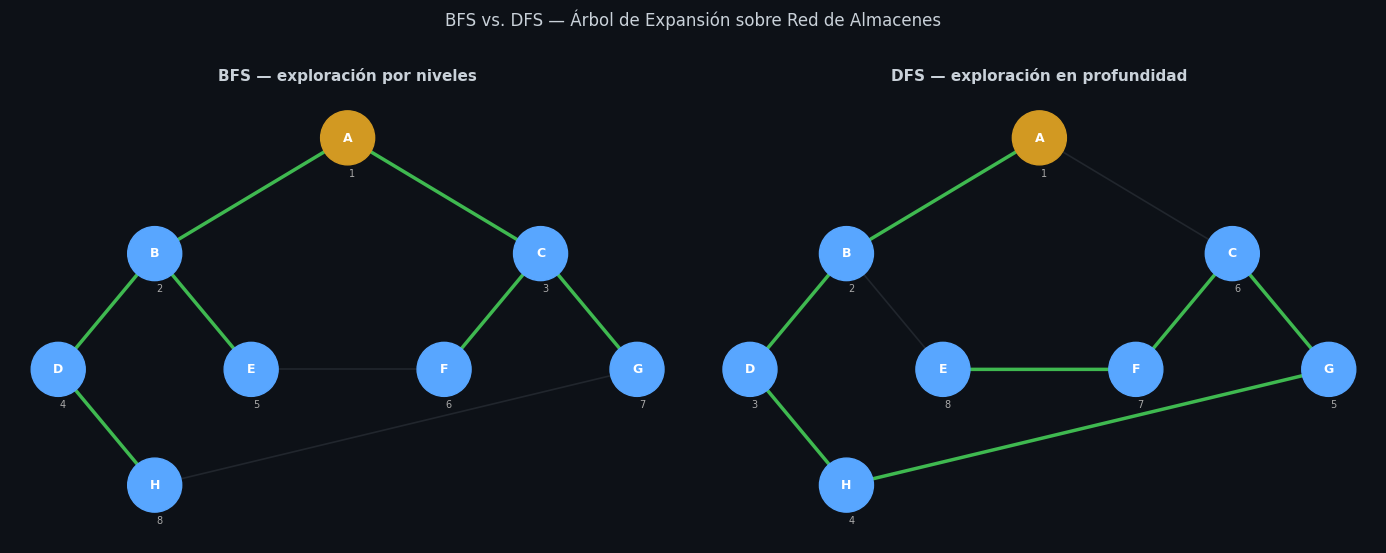

In [28]:
# ── Comparación visual BFS vs DFS ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for ax in (ax1, ax2): ax.axis('off'); ax.set_aspect('equal')

def _dibujar_arbol_recorrido(ax, grafo, posiciones, padres, orden, titulo):
    ax.set_title(titulo, fontsize=11)
    trazadas = set()
    for u in grafo:
        xu, yu = posiciones[u]
        for v in grafo[u]:
            key = tuple(sorted([u,v]))
            if key in trazadas: continue
            trazadas.add(key)
            xv, yv = posiciones[v]
            ax.plot([xu,xv],[yu,yv],'-',color='#21262d',lw=1.2,zorder=1)
    for v in orden:
        p = padres.get(v)
        if p:
            xu,yu = posiciones[p]; xv,yv = posiciones[v]
            ax.annotate('', xy=(xv,yv), xytext=(xu,yu),
                        arrowprops=dict(arrowstyle='->', color=GREEN, lw=2.5), zorder=2)
    for i,(v) in enumerate(orden):
        x,y = posiciones[v]
        col = ORANGE if i == 0 else ACCENT
        ax.add_patch(plt.Circle((x,y), 0.28, color=col, zorder=3))
        ax.text(x,y,v,ha='center',va='center',fontsize=9,color='white',fontweight='bold',zorder=4)
        ax.text(x+0.05, y-0.40, str(i+1), ha='center', fontsize=7, color='#aaa', zorder=4)
    xs=[p[0] for p in posiciones.values()]; ys=[p[1] for p in posiciones.values()]
    ax.set_xlim(min(xs)-0.5, max(xs)+0.5); ax.set_ylim(min(ys)-0.6, max(ys)+0.5)

_, dist_b, pad_b = bfs(g, 'A')
ord_b = sorted(dist_b, key=lambda v: (dist_b[v], v))
_dibujar_arbol_recorrido(ax1, g, pos_almacenes, pad_b, ord_b, 'BFS — exploración por niveles')

ord_d, pad_d, _, _ = dfs(g, 'A')
_dibujar_arbol_recorrido(ax2, g, pos_almacenes, pad_d, ord_d, 'DFS — exploración en profundidad')

plt.suptitle('BFS vs. DFS — Árbol de Expansión sobre Red de Almacenes', fontsize=12)
plt.tight_layout(); plt.show()


---
## 3.8 Detección de Ciclos en Grafos

Un ciclo en un grafo no dirigido existe si durante el DFS se encuentra una **arista de retroceso** (*back edge*): una arista hacia un vértice ya visitado que no es el padre inmediato del vértice actual.


In [29]:
def tiene_ciclo(grafo):
    """
    Detección de ciclos en grafo no dirigido mediante DFS.
    Retorna (True/False, ciclo_encontrado).
    O(V+E) tiempo.
    """
    visitados = set()
    ciclo_info = []

    def _dfs(u, padre):
        visitados.add(u)
        for v in grafo[u]:
            if v not in visitados:
                if _dfs(v, u):
                    return True
            elif v != padre:
                ciclo_info.append((u, v))
                return True
        return False

    for v in sorted(grafo):
        if v not in visitados:
            if _dfs(v, None):
                return True, ciclo_info
    return False, []

# Grafo con ciclo
g_ciclo = crear_grafo()
for u, v in [('X','Y'),('Y','Z'),('Z','W'),('W','X'),('X','Z')]:
    agregar_arista(g_ciclo, u, v)

# Grafo sin ciclo (árbol)
g_arbol = crear_grafo()
for u, v in [('1','2'),('1','3'),('2','4'),('2','5'),('3','6')]:
    agregar_arista(g_arbol, u, v)

hay_ciclo, info = tiene_ciclo(g)
print(f"Red de almacenes — tiene ciclo: {hay_ciclo}  info: {info}")

hay_ciclo2, info2 = tiene_ciclo(g_ciclo)
print(f"Grafo X-Y-Z-W     — tiene ciclo: {hay_ciclo2}  info: {info2}")

hay_ciclo3, info3 = tiene_ciclo(g_arbol)
print(f"Árbol 1-2-3-4-5-6 — tiene ciclo: {hay_ciclo3}  info: {info3}")


Red de almacenes — tiene ciclo: True  info: [('C', 'A')]
Grafo X-Y-Z-W     — tiene ciclo: True  info: [('X', 'W')]
Árbol 1-2-3-4-5-6 — tiene ciclo: False  info: []


---
## 3.9 Camino Más Corto (BFS en grafos no ponderados)

En grafos sin pesos en las aristas, BFS garantiza encontrar el **camino más corto** (en número de aristas) entre el nodo origen y cualquier otro nodo. La reconstrucción del camino se hace retrocediendo a través del diccionario de padres desde el destino hasta el origen.


In [30]:
def camino_mas_corto(grafo, origen, destino):
    """
    Camino mínimo (aristas) entre origen y destino usando BFS.
    Retorna (camino, longitud) o (None, -1) si no existe.
    O(V+E) tiempo.
    """
    _, dist, padres = bfs(grafo, origen)
    if destino not in dist:
        return None, -1

    # Reconstrucción
    camino = []
    actual = destino
    while actual is not None:
        camino.append(actual)
        actual = padres[actual]
    camino.reverse()
    return camino, dist[destino]

# Todos los caminos desde A
print("Caminos más cortos desde A:")
for destino in sorted(g.keys()):
    cam, lng = camino_mas_corto(g, 'A', destino)
    print(f"  A → {destino}: {' → '.join(cam)}  ({lng} salto{'s' if lng != 1 else ''})")


Caminos más cortos desde A:
  A → A: A  (0 saltos)
  A → B: A → B  (1 salto)
  A → C: A → C  (1 salto)
  A → D: A → B → D  (2 saltos)
  A → E: A → B → E  (2 saltos)
  A → F: A → C → F  (2 saltos)
  A → G: A → C → G  (2 saltos)
  A → H: A → B → D → H  (3 saltos)


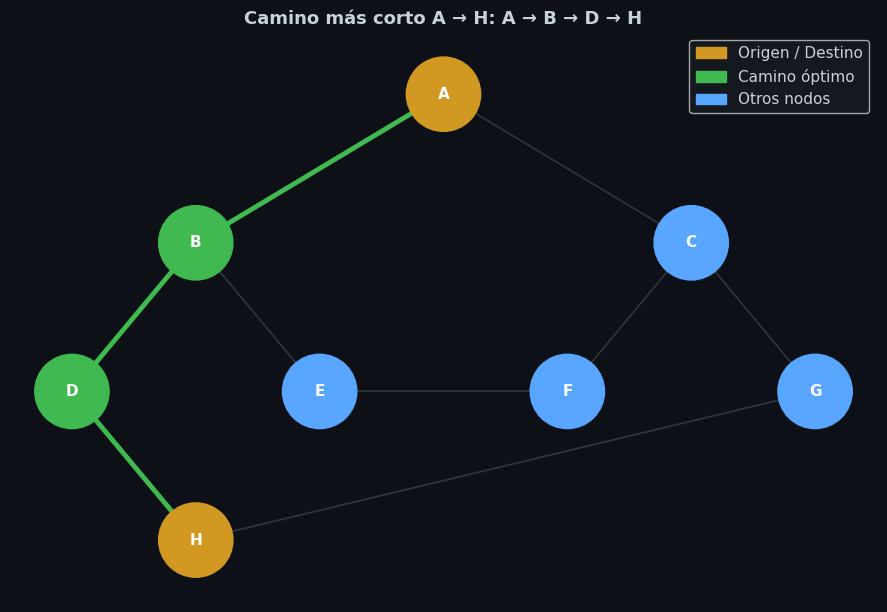

In [31]:
def visualizar_camino(grafo, posiciones, camino, titulo='Camino más corto'):
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_title(titulo); ax.axis('off'); ax.set_aspect('equal')

    aristas_camino = set()
    for i in range(len(camino)-1):
        aristas_camino.add(tuple(sorted([camino[i], camino[i+1]])))

    trazadas = set()
    for u in grafo:
        xu, yu = posiciones[u]
        for v in grafo[u]:
            key = tuple(sorted([u,v]))
            if key in trazadas: continue
            trazadas.add(key)
            xv, yv = posiciones[v]
            es_cam = key in aristas_camino
            col = GREEN if es_cam else '#30363d'
            lw  = 3.5   if es_cam else 1.2
            ax.plot([xu,xv],[yu,yv],'-',color=col,lw=lw,zorder=1)

    for v, (x,y) in posiciones.items():
        col = ORANGE if v in (camino[0], camino[-1]) else               GREEN  if v in camino else ACCENT
        ax.add_patch(plt.Circle((x,y),0.30,color=col,zorder=2))
        ax.text(x,y,v,ha='center',va='center',fontsize=11,color='white',fontweight='bold',zorder=3)

    legend = [
        mpatches.Patch(color=ORANGE, label='Origen / Destino'),
        mpatches.Patch(color=GREEN,  label='Camino óptimo'),
        mpatches.Patch(color=ACCENT, label='Otros nodos'),
    ]
    ax.legend(handles=legend, loc='upper right')
    xs=[p[0] for p in posiciones.values()]; ys=[p[1] for p in posiciones.values()]
    ax.set_xlim(min(xs)-0.5, max(xs)+0.5); ax.set_ylim(min(ys)-0.5, max(ys)+0.5)
    plt.tight_layout(); plt.show()

cam_AH, _ = camino_mas_corto(g, 'A', 'H')
visualizar_camino(g, pos_almacenes, cam_AH,
                  titulo=f"Camino más corto A → H: {' → '.join(cam_AH)}")


---
## 3.10 Componentes Conexas

Un grafo puede estar formado por múltiples subgrafos sin conexión entre sí (**componentes conexas**). El algoritmo recorre todos los vértices no visitados con DFS, asignando un identificador de componente a cada grupo alcanzable.


In [32]:
def componentes_conexas(grafo):
    """
    Encuentra todas las componentes conexas del grafo.
    Retorna lista de sets.  O(V+E) tiempo.
    """
    visitados = set()
    componentes = []

    def _dfs(u, comp):
        visitados.add(u)
        comp.add(u)
        for v in grafo[u]:
            if v not in visitados:
                _dfs(v, comp)

    for v in sorted(grafo):
        if v not in visitados:
            comp = set()
            _dfs(v, comp)
            componentes.append(comp)

    return componentes

def es_conexo(grafo):
    return len(componentes_conexas(grafo)) == 1

comps = componentes_conexas(g)
print(f"Red de almacenes — conexo: {es_conexo(g)}")
print(f"  Componentes: {[sorted(c) for c in comps]}")

# Grafo desconexo para demostración
g_desc = crear_grafo()
for u, v in [('1','2'),('2','3'),('4','5'),('6','7'),('7','8')]:
    agregar_arista(g_desc, u, v)
comps2 = componentes_conexas(g_desc)
print(f"\nGrafo desconexo — conexo: {es_conexo(g_desc)}")
for i, c in enumerate(comps2):
    print(f"  Componente {i+1}: {sorted(c)}")


Red de almacenes — conexo: True
  Componentes: [['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']]

Grafo desconexo — conexo: False
  Componente 1: ['1', '2', '3']
  Componente 2: ['4', '5']
  Componente 3: ['6', '7', '8']


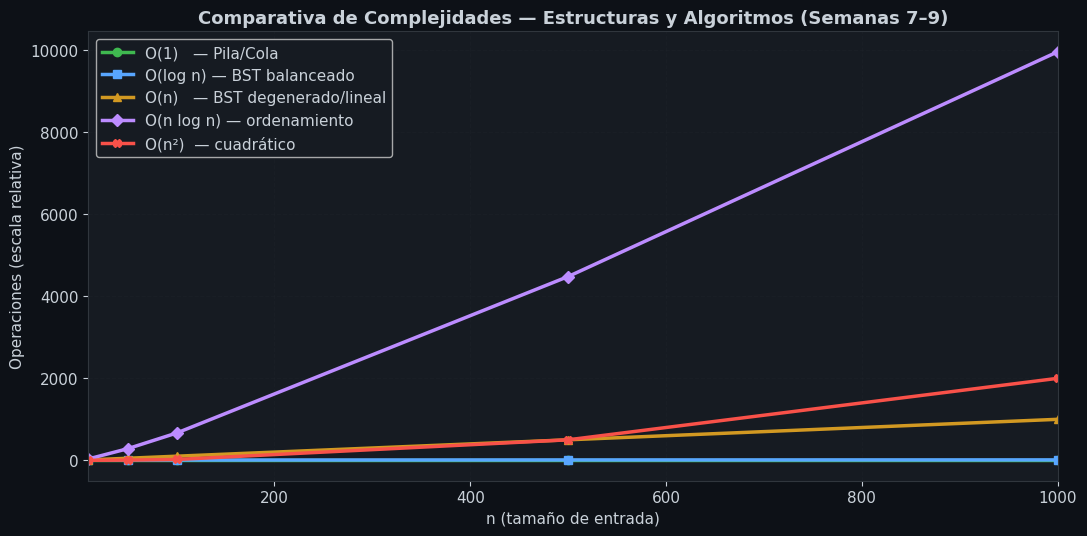

In [33]:
# ── Gráfica: análisis comparativo de complejidades ────────────────────────────
categorias = ['Pila O(1)', 'Cola O(1)', 'BST O(log n)', 'BST O(n)', 'BFS/DFS O(V+E)', 'Busqueda Lineal O(n)']
ns = np.array([10, 50, 100, 500, 1000])

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(ns, np.ones_like(ns),       'o-', color=GREEN,  label='O(1)   — Pila/Cola',           lw=2.5)
ax.plot(ns, np.log2(ns),            's-', color=ACCENT, label='O(log n) — BST balanceado',     lw=2.5)
ax.plot(ns, ns,                     '^-', color=ORANGE, label='O(n)   — BST degenerado/lineal',lw=2.5)
ax.plot(ns, ns * np.log2(ns),       'D-', color=PURPLE, label='O(n log n) — ordenamiento',     lw=2.5)
ax.plot(ns, ns**2 / 500,            'X-', color=RED,    label='O(n²)  — cuadrático',           lw=2.5)
ax.set_xlabel('n (tamaño de entrada)')
ax.set_ylabel('Operaciones (escala relativa)')
ax.set_title('Comparativa de Complejidades — Estructuras y Algoritmos (Semanas 7–9)')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
ax.set_xlim(10, 1000)
plt.tight_layout(); plt.show()


---
## Resumen Comparativo de Estructuras y Algoritmos

| Estructura / Algoritmo | Política | Inserción | Búsqueda | Eliminación | Espacio |
|------------------------|----------|-----------|----------|-------------|---------|
| Pila (Stack) | LIFO | O(1) | O(n) | O(1) | O(n) |
| Cola (Queue, dos pilas) | FIFO | O(1) | O(n) | O(1) amort. | O(n) |
| Stack Monotónico | Orden parcial | O(1) amort. | O(1) | O(1) amort. | O(n) |
| BST balanceado | Orden total | O(log n) | O(log n) | O(log n) | O(n) |
| BST degenerado | Orden total | O(n) | O(n) | O(n) | O(n) |
| AVL | Orden total | O(log n) | O(log n) | O(log n) | O(n) |
| Grafo — BFS | Anchura | O(V+E) | O(V+E) | — | O(V) |
| Grafo — DFS | Profundidad | O(V+E) | O(V+E) | — | O(h) |

---


---
# IV. Conclusión

El recorrido por las semanas 7, 8 y 9 consolida una visión íntegra del continuo que va desde las estructuras lineales más elementales hasta las estructuras de datos no lineales y las redes de relaciones complejas.

**Estructuras lineales (Semana 7).** La pila y la cola no son simples contenedores; son contratos de acceso que determinan la semántica completa de algoritmos superiores. La implementación de la cola con dos pilas ilustra cómo una restricción aparente (no usar módulos externos) estimula soluciones ingeniosas con garantías amortizadas. El stack monotónico eleva esta abstracción al añadir invariantes de orden, resolviendo en O(n) problemas que la fuerza bruta resolvería en O(n²). El sistema de atención médica demuestra que la elección correcta de estructura de datos transforma un problema de lógica compleja en un conjunto de operaciones primitivas compostas.

**Árboles binarios (Semana 8).** El BST introduce la dimensión logarítmica: la misma búsqueda que en un arreglo requiere O(n) comparaciones, aquí necesita O(log n) si el árbol está balanceado. La trampa del árbol degenerado (inserciones ordenadas) motivó el desarrollo del AVL, que impone un coste adicional constante por inserción a cambio de garantizar invariablemente la altura óptima. La aplicación al inventario de computadores confirma que estos árboles no son estructuras académicas: cualquier sistema que necesite búsqueda eficiente más recorrido ordenado sin estructura auxiliar de índice puede beneficiarse de ellos.

**Grafos (Semana 9).** Los grafos generalizan todas las estructuras anteriores: un árbol es un grafo acíclico conexo, y una lista enlazada es un grafo degenerado. BFS y DFS no son simplemente formas de recorrer un grafo; son *esquemas algorítmicos* sobre los que se construyen caminos mínimos, detección de componentes, análisis de ciclos y ordenamientos topológicos. La red de almacenes ilustra un caso de uso directo en logística: dado un mapa de conectividad, BFS responde en tiempo lineal cuál es la ruta de menor número de saltos entre dos puntos cualesquiera de la red.

La progresión O(n) → O(log n) → O(V+E) resume la filosofía del módulo: cada estructura de datos impone una organización que permite explotar propiedades matemáticas para reducir el coste computacional. Elegir la estructura correcta no es un detalle de implementación; es la decisión de diseño más importante de cualquier sistema de software.
